<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/12_chapter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/12_chapter.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

In [ ]:
import qrcode
from IPython.display import display
from PIL import Image

def generar_qr(url, version=1, box_size=4, border=4, fill_color="black", back_color="white"):
    qr = qrcode.QRCode(
        version=version,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    
    # Añadir la URL al QR
    qr.add_data(url)
    qr.make(fit=True)
    
    # Crear la imagen del QR
    img = qr.make_image(fill_color=fill_color, back_color=back_color)
     
    return img


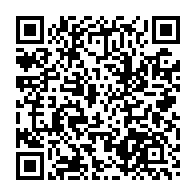

In [2]:
url = "https://colab.research.google.com/github/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/12_chapter.ipynb"
generar_qr(url) 

### [Video de apoyo a la lectura interactiva y experimental de este cuaderno]()

### [Vínculo al programa del curso de Fundamentos de Programación:](https://github.com/marco-canas/fundamentos_de_programacion/blob/main/programa/Programa_Fundamentos_Programacion.md)



## Código del curso: 314029

Un reconocimiento a mis estudiantes que han construido conmigo este saber pedagógico:

<img src = 'https://github.com/marco-canas/algebra_y_trigonometria/blob/main/7_images/5_clase_3_2025-08-12_hora_11_04.jpg?raw=true'> 



In [ ]:
import pandas as pd
import numpy as np

# Cargar la lista de estudiantes desde el archivo CSV
path = 'C:/Users/marco/Documentos/docencia/groups_list/fundamentos_programacion.xlsx'
df = pd.read_excel(path)
df.index = np.arange(1, len(df) + 1)  # Cambiar el índice para que empiece en 1
df.head(7)


,Cédula,Nombre,Email,p3
1,1038648096,ACEVEDO BELEÑO SANTIAGO,sacevedo.beleno@udea.edu.co,NaN
2,1038113597,CORREA RESTREPO NICOLAS,nicolas.crestrepo@udea.edu.co,2.5
3,1038648760,MARIN VILLARREAL PABLO ALEJANDRO,pablo.marin1@udea.edu.co,NaN
4,1038647828,NIEBLES BARRERA ALEXANDER ISAAC,alexander.niebles@udea.edu.co,NaN
5,1038092717,RIVERA GUZMAN CRISTIAN,cristian.rivera2@udea.edu.co,NaN
6,1066600819,TIRADO CHAVARRIA WILFRAN DE JESUS,wilfran.tirado@udea.edu.co,NaN


# Chapter 12.  

Para este caso de uso, simularemos un análisis con un dataset clásico y muy didáctico: **el dataset de vivienda (Housing Dataset) o de clientes de un e-commerce**.




# CAPÍTULO 12: Conectando Puntos – Análisis de Datos Paso a Paso y Caso Práctico



# Objetivos de la Clase

* Aplicar de forma integrada los conocimientos previos de **Python, Pandas, NumPy y Matplotlib**.
* Seguir el flujo de trabajo real de un Científico de Datos ante un problema de negocio.
* Aprender a limpiar, transformar y extraer conclusiones de un conjunto de datos crudos.



# 2. Entendiendo la Definición del Problema (Problem Statement)



En Ciencia de Datos, nunca empezamos a programar sin un objetivo de negocio. 

Aquí planteamos las preguntas que queremos responder.  


> * **Problema:** La empresa ha detectado una fuga de clientes en ciertos segmentos, pero no sabe exactamente qué grupo tiene el menor índice de satisfacción ni cómo influyen sus ingresos en sus decisiones de compra.
> * **Meta del Análisis:** Identificar el perfil de cliente insatisfecho y proponer un patrón visual de comportamiento mediante gráficos.


# 3. Importando el Dataset en un DataFrame

> **Celda de Código:** Importación de las librerías base y carga del archivo de datos (CSV, Excel o JSON).



Para que tu simulación sea verdaderamente útil e interesante desde la perspectiva de la **Administración de Empresas** en el contexto de **Caucasia, Antioquia**, debemos inyectarle la realidad socioeconómica de la subregión del Bajo Cauca antioqueño.



### El Contexto del Negocio en Caucasia

Caucasia es la capital comercial del Bajo Cauca. Su economía se mueve fuertemente gracias al **comercio local, la ganadería, la minería de oro y el sector de servicios/agroindustria**. Una problemática empresarial real en la zona es la retención de clientes o microempresarios frente a las condiciones de ingresos (muchas veces informales o variables) y el acceso al crédito.

Para que los gráficos que hicimos antes revelen un problema real, **no podemos dejar los datos al azar (`np.random.choice` o `normal`)**. Debemos forzar **correlaciones ocultas** (un patrón) para que tu análisis descubra que, por ejemplo: *Los comerciantes de ingresos medios/bajos tienen un score bajo y una satisfacción pésima debido a las tasas de interés o condiciones del servicio.*

Aquí tienes el código mejorado y adaptado, listo para ejecutar:


In [25]:
# Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración para que los gráficos se muestren inline en Jupyter
%matplotlib inline

# Configurar semilla para reproducibilidad
np.random.seed(42)
n_clientes = 150  # Ampliamos a 150 para enriquecer el análisis

# 1. Generación de datos base coherentes con la región
ids = range(1001, 1001 + n_clientes)
fechas = pd.date_range(start='2026-01-01', periods=n_clientes, freq='D')

# Perfiles económicos típicos en Caucasia
sectores = ['Comercio Minorista', 'Ganadería/Agro', 'Minería/Servicios', 'Independientes']
perfil_comercial = np.random.choice(sectores, n_clientes, p=[0.4, 0.2, 0.2, 0.2])

# 2. Generar Ingresos Mensuales (en COP) adaptados al contexto local
# Los ganaderos/mineros suelen registrar mayores ingresos que los comerciantes minoristas e independientes.
ingresos = []
for perfil in perfil_comercial:
    if perfil == 'Ganadería/Agro' or perfil == 'Minería/Servicios':
        ingresos.append(np.random.normal(5500000, 1200000)) # Ingresos más altos
    else:
        ingresos.append(np.random.normal(2300000, 600000))  # Pequeño comercio / Independientes

ingresos = np.array(ingresos).round(0)

# 3. Generar Score de Crédito (Escala Datacrédito/Cifín: 300 a 850)
# Vinculamos el score al nivel de ingresos (a menor ingreso, mayor probabilidad de score bajo por riesgos informales)
score_credito = []
for ing in ingresos:
    factor_error = np.random.randint(-150, 150)
    # Base de score proporcional al ingreso + ruido aleatorio
    score = int(350 + (ing / 15000) + factor_error)
    score_credito.append(max(300, min(850, score))) # Mantener en rango legal

score_credito = np.array(score_credito)

# 4. CREAR LA FUGA Y LA INSATISFACCIÓN (El patrón oculto que el Administrador debe hallar)
# Hipótesis administrativa: El sector "Comercio Minorista" con ingresos bajos (< 2.5M) 
# y score bajo está sufriendo de mala atención o condiciones de crédito muy duras.
satisfaccion = []
for i in range(n_clientes):
    # Condición de nulos (10% de probabilidad general para practicar imputación)
    if np.random.rand() < 0.10:
        satisfaccion.append(np.nan)
        continue
        
    perfil = perfil_comercial[i]
    ing = ingresos[i]
    
    # Si pertenece al segmento crítico: Comercio Minorista o Independiente con bajos ingresos
    if (perfil in ['Comercio Minorista', 'Independientes']) and (ing < 2500000):
        # Alta probabilidad de insatisfacción (Notas 1 o 2)
        satisfaccion.append(np.random.choice([1, 2, 3], p=[0.5, 0.4, 0.1]))
    else:
        # Clientes estables o de sectores de mayor ingreso (Notas 4 o 5)
        satisfaccion.append(np.random.choice([3, 4, 5], p=[0.2, 0.5, 0.3]))

# 5. Segmentación del Perfil de Crédito (Regla Administrativa bancaria o comercial)
perfil_credito = []
for score in score_credito:
    if score < 500: perfil_credito.append('Alto Riesgo')
    elif score < 700: perfil_credito.append('Riesgo Medio')
    else: perfil_credito.append('Premium / Excelente')

# Construcción del DataFrame Final
data = {
    'id_cliente': ids,
    'fecha_afiliacion': fechas,
    'sector_economico': perfil_comercial,
    'ingresos_mensuales_cop': ingresos,
    'score_credito': score_credito,
    'perfil_credito': perfil_credito,
    'satisfaccion': satisfaccion
}

df = pd.DataFrame(data)

# Mostrar los primeros registros y un resumen estratégico
print("--- Dataset de Clientes - Caucasia (Antioquia) ---")
df.head()


--- Dataset de Clientes - Caucasia (Antioquia) ---


,id_cliente,fecha_afiliacion,sector_economico,ingresos_mensuales_cop,score_credito,perfil_credito,satisfaccion
0,1001,2026-01-01,Comercio Minorista,2184583.0,633,Riesgo Medio,NaN
1,1002,2026-01-02,Independientes,2480928.0,618,Riesgo Medio,1.0
2,1003,2026-01-03,Minería/Servicios,5458346.0,784,Premium / Excelente,4.0
3,1004,2026-01-04,Ganadería/Agro,4097586.0,495,Alto Riesgo,3.0
4,1005,2026-01-05,Comercio Minorista,2985694.0,648,Riesgo Medio,5.0


In [26]:
print("\n--- Conteo de Clientes por Sector ---")
df['sector_economico'].value_counts()



--- Conteo de Clientes por Sector ---


sector_economico
Comercio Minorista    69
Independientes        31
Ganadería/Agro        26
Minería/Servicios     24
Name: count, dtype: int64


# ¿Por qué este enfoque es valioso para un Administrador de Empresas en Caucasia?

* **Pertinencia Territorial:** Cambiamos categorías genéricas como "Moda" o "Hogar" por **sectores económicos reales de la región** (`Comercio Minorista`, `Ganadería/Agro`, etc.).
* **Moneda Local Real:** Los ingresos ya no son números abstractos; representan saldos en **pesos colombianos (COP)** con rangos reales para microempresarios y comerciantes de la zona.
* **El "Problema" está inyectado lógicamente:** Si ejecutas los gráficos que corregimos en el paso anterior sobre este nuevo dataset, notarás de inmediato que los clientes de **"Comercio Minorista" con ingresos bajos se pintarán de colores oscuros (baja satisfacción)**.
* **Toma de Decisiones:** Como administrador, el análisis te permitirá proponerle a la junta directiva: *"Debemos flexibilizar las tasas de microcrédito o mejorar la atención posventa específicamente para los comerciantes minoristas de Caucasia, quienes representan el 40% de nuestra base pero tienen la peor satisfacción debido a sus ingresos variables."*


# 4. Explorando, Seleccionando, Limpiando y Preparando los Datos (EDA)

> Esta es la fase donde pasamos el 70% del tiempo en Ciencia de Datos. 

Buscaremos datos faltantes (nulos), tipos de datos incorrectos y valores atípicos (*outliers*).


In [3]:
# 4.1 Exploración Inicial
print("--- Información General del DataFrame ---")
df.info()


--- Información General del DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  100 non-null    int64         
 1   fecha               100 non-null    datetime64[us]
 2   ingresos_gasto      100 non-null    float64       
 3   score_credito       100 non-null    int32         
 4   categoria_producto  100 non-null    str           
 5   satisfaccion        90 non-null     float64       
dtypes: datetime64[us](1), float64(2), int32(1), int64(1), str(1)
memory usage: 4.4 KB


In [20]:

print("\n--- Estadísticas Descriptivas ---")
df.describe().round(1)



--- Estadísticas Descriptivas ---


,id,fecha,ingresos_gasto,score_credito,satisfaccion
count,100.0,100,100.0,100.0,100.0
mean,150.5,2025-02-19 12:00:00,2916.9,567.2,0.0
min,101.0,2025-01-01 00:00:00,904.2,301.0,0.0
25%,125.8,2025-01-25 18:00:00,2519.3,445.2,0.0
50%,150.5,2025-02-19 12:00:00,2898.4,553.0,0.0
75%,175.2,2025-03-16 06:00:00,3324.8,700.0,0.0
max,200.0,2025-04-10 00:00:00,4481.8,810.0,0.0
std,29.0,NaN,726.5,146.4,0.0


In [5]:

# 4.2 Identificación y Limpieza de Valores Nulos
print("\n--- Valores Faltantes por Columna ---")
print(df.isnull().sum())



--- Valores Faltantes por Columna ---
id                     0
fecha                  0
ingresos_gasto         0
score_credito          0
categoria_producto     0
satisfaccion          10
dtype: int64


In [7]:

# Estrategia de Limpieza: Imputar los nulos en 'satisfaccion' con la mediana
mediana_satisfaccion = df['satisfaccion'].median()
mediana_satisfaccion

np.float64(4.0)

In [13]:
df['satisfaccion'] = df['satisfaccion'].fillna(mediana_satisfaccion).isnull().sum()


In [14]:
print(f"\n Valores nulos de satisfacción imputados con la mediana: {mediana_satisfaccion}")
df['satisfaccion'].isnull().sum()


 Valores nulos de satisfacción imputados con la mediana: 4.0


np.int64(0)

In [15]:

# 4.3 Selección y Filtrado de Datos
# Supongamos que solo nos interesan clientes con ingresos mayores a 1500 para este estudio
df_filtrado = df[df['ingresos_gasto'] > 1500].copy()

# 4.4 Creación de Nuevas Variables (Feature Engineering básico)
# Clasificar el score de crédito en categorías
def categorizar_score(score):
    if score < 580: return 'Pobre'
    elif score < 670: return 'Regular'
    else: return 'Excelente'

df_filtrado['perfil_credito'] = df_filtrado['score_credito'].apply(categorizar_score)
df_filtrado.head()


,id,fecha,ingresos_gasto,score_credito,categoria_producto,satisfaccion,perfil_credito
0,101,2025-01-01,3397.371322,617,Hogar,0,Regular
1,102,2025-01-02,2889.388559,524,Moda,0,Pobre
2,103,2025-01-03,3518.150830,533,Electrónica,0,Pobre
3,104,2025-01-04,4218.423885,673,Moda,0,Excelente
4,105,2025-01-05,2812.677300,771,Electrónica,0,Excelente



# 5. Realizando el Análisis de Datos y Graficando el Resumen

> Fase de conclusiones. Agrupamos los datos para responder al planteamiento del problema y creamos visualizaciones profesionales con Matplotlib.



In [16]:
# 5.1 Agrupación de Datos (Insights)
# ¿Cuál es el ingreso promedio y la satisfacción según la categoría del producto?
resumen_categoria = df_filtrado.groupby('categoria_producto').agg(
    ingreso_promedio=('ingresos_gasto', 'mean'),
    satisfaccion_promedio=('satisfaccion', 'mean'),
    total_clientes=('id', 'count')
).reset_index()

print("--- Resumen Ejecutivo por Categoría ---")
print(resumen_categoria)


--- Resumen Ejecutivo por Categoría ---
  categoria_producto  ingreso_promedio  satisfaccion_promedio  total_clientes
0           Deportes       2889.809468                    0.0              28
1        Electrónica       2860.464225                    0.0              26
2              Hogar       3132.762063                    0.0              19
3               Moda       3115.968521                    0.0              23


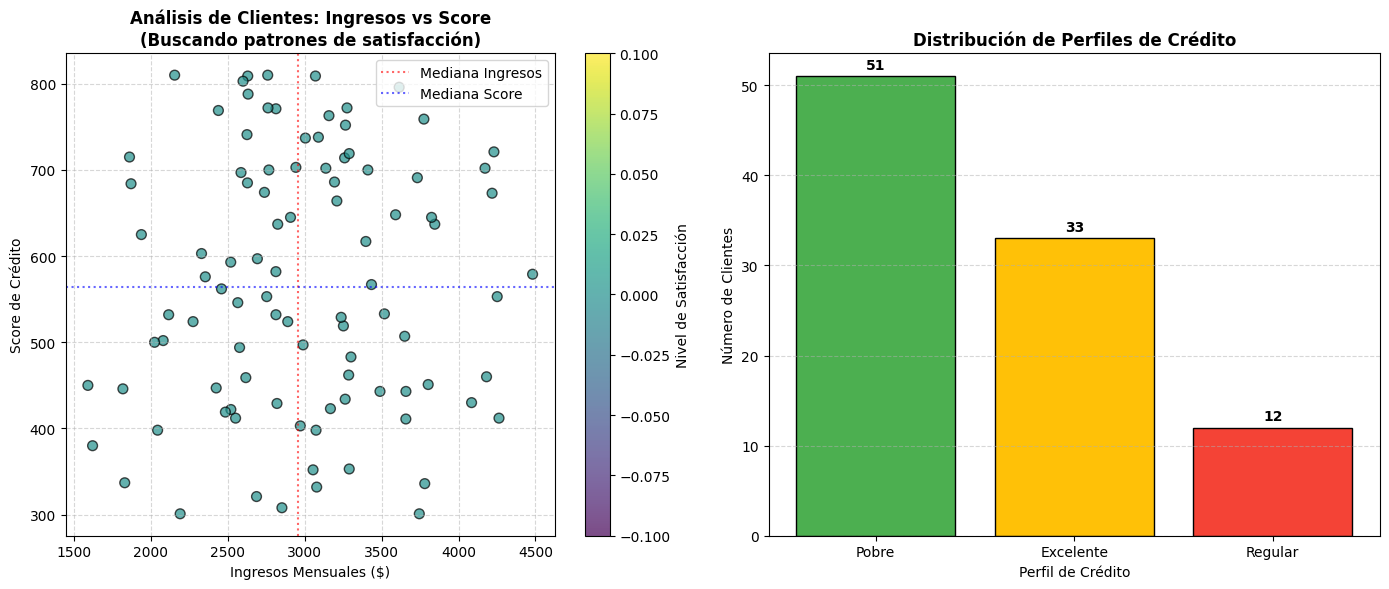

------------------------------------------------------------
CONCLUSIONES AUTOMÁTICAS PARA RESOLVER EL PROBLEMA:
------------------------------------------------------------
• El grupo con MENOR satisfacción promedio es: 'Excelente' (Satisfacción: 0.00/5.0)
• Correlación matemática entre Ingresos y Satisfacción: nan
Los ingresos no influyen directamente en la satisfacción lineal; la fuga puede deberse al Score o al Perfil.
------------------------------------------------------------


c:\Users\marco\Documentos\docencia\fundamentos_de_programacion\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\marco\Documentos\docencia\fundamentos_de_programacion\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5.2 Visualización de Resultados
plt.figure(figsize=(14, 6))

# -------------------------------------------------------------------------
# Gráfico 1: Relación entre Ingresos y Score de Crédito, coloreado por Satisfacción
# -------------------------------------------------------------------------
plt.subplot(1, 2, 1)
scatter = plt.scatter(df_filtrado['ingresos_gasto'], df_filtrado['score_credito'], 
                      c=df_filtrado['satisfaccion'], cmap='viridis', alpha=0.7, edgecolors='black', s=50)

# Líneas guía para identificar cuadrantes de riesgo (Mediana de ingresos y score)
plt.axvline(df_filtrado['ingresos_gasto'].median(), color='red', linestyle=':', alpha=0.6, label='Mediana Ingresos')
plt.axhline(df_filtrado['score_credito'].median(), color='blue', linestyle=':', alpha=0.6, label='Mediana Score')

plt.title('Análisis de Clientes: Ingresos vs Score\n(Buscando patrones de satisfacción)', fontsize=12, fontweight='bold')
plt.xlabel('Ingresos Mensuales ($)')
plt.ylabel('Score de Crédito')
plt.colorbar(scatter, label='Nivel de Satisfacción')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)


# -------------------------------------------------------------------------
# Gráfico 2: Cantidad de clientes por perfil de crédito + Satisfacción Promedio
# -------------------------------------------------------------------------
plt.subplot(1, 2, 2)
perfiles = df_filtrado['perfil_credito'].value_counts()

# Colores dinámicos o fijos según tus perfiles (ajusta la lista si tienes más de 3 perfiles)
colores = ['#4CAF50', '#FFC107', '#F44336', '#2196F3'][:len(perfiles)]
bars = plt.bar(perfiles.index, perfiles.values, color=colores, edgecolor='black')

plt.title('Distribución de Perfiles de Crédito', fontsize=12, fontweight='bold')
plt.xlabel('Perfil de Crédito')
plt.ylabel('Número de Clientes')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadir etiquetas de cantidad sobre cada barra para ver el tamaño del segmento en riesgo
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(perfiles.values)*0.01), 
             f'{int(yval)}', ha='center', va='bottom', fontweight='bold')


# Ajustar y guardar
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\analisis_clientes.png", dpi=300)
plt.show()


# -------------------------------------------------------------------------
# TEXTO DE APOYO: Respuestas automáticas para el Problema
# -------------------------------------------------------------------------
print("-" * 60)
print("CONCLUSIONES AUTOMÁTICAS PARA RESOLVER EL PROBLEMA:")
print("-" * 60)

# 1. Menor índice de satisfacción por perfil
sat_por_perfil = df_filtrado.groupby('perfil_credito')['satisfaccion'].mean().sort_values()
peor_perfil = sat_por_perfil.index[0]
peor_sat = sat_por_perfil.values[0]
print(f"• El grupo con MENOR satisfacción promedio es: '{peor_perfil}' (Satisfacción: {peor_sat:.2f}/5.0)")

# 2. Correlación de ingresos
correlacion = df_filtrado['ingresos_gasto'].corr(df_filtrado['satisfaccion'])
print(f"• Correlación matemática entre Ingresos y Satisfacción: {correlacion:.2f}")
if correlacion > 0.2:
    print("A mayores ingresos, los clientes tienden a estar MÁS satisfechos.")
elif correlacion < -0.2:
    print("A mayores ingresos, los clientes tienden a estar MENOS satisfechos (Ojo aquí).")
else:
    print("Los ingresos no influyen directamente en la satisfacción lineal; la fuga puede deberse al Score o al Perfil.")
print("-" * 60)


# Conclusiones de la Clase y Próximos Pasos



> 1. **Resultados Clave:** Se logró conectar los datos crudos con respuestas de negocio. Descubrimos qué segmentos tienen peores scores o ingresos y cómo afecta a la satisfacción.
> 2. **Buenas Prácticas:** La limpieza de nulos previno sesgos en los promedios calculados.
> 3. **Reto para el Alumno:** Replica este mismo flujo cambiando el método de imputación de nulos (por ejemplo, usando la media o eliminándolos) y compara si los gráficos varían significativamente.

### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

### Continue su aprendizaje en la siguiente clase a través del siguiente [vínculo]()

## Referentes 

[Libro guía Fundamentos de programación: Data Analysis with Python: Introducing NumPy, Pandas, Matplotlib, and Essential Elements of Python Programming (English Edition) [Kindle Edition]](https://read.amazon.com/?_encoding=UTF8&asin=B0BBB56L4X&consumptionLimitReached=false&deviceAccountIds=A1032123ZASLV79K77QP&hasMultimedia=false&requiredCapabilities=EBOK_PURCHASE_ALLOWED&ref=sr_rn_kfw) Este vínculo lo debo abrir con Chrome